# Earthquake window -- coherent analysis (v1)

A single, connected flow:

1. **Read** the folder (only read).
2. **Overview** of every sensor and pick the time window.
3. **Accelerogram** of all sensors (overlaid or separate).
4. **Corrections + band-pass** (the inputs that feed the rest).
5. **Fourier spectra** of the filtered data, 3 components, all sensors.
6. **Fourier filtered vs unfiltered**.
7. **Predominant frequencies** from the ambient (STA/LTA) windows.
8. **Correlation between sensors** (transfer function + coherence).

Units: package is SI (m/s^2); pass ``factor=1/9.81`` to display g.

## 0. Imports

In [1]:
%matplotlib inline

import numpy as np
from datetime import datetime

from asdea_sensors import SensorDataset
from asdea_sensors.config import settings

## 1. Read the data (only read)

In [2]:
folder = r"C:\Users\ppala\Desktop\02_31MAY2026"

ds = SensorDataset(folder, verbose=True)
print("devices    :", ds.devices)
print("max points :", format(ds.max_points, ","))

------------------------------------------------------------
SensorDataset
------------------------------------------------------------
path        : C:\Users\ppala\Desktop\02_31MAY2026
files       : 32
time span   : 2026-05-31 14:52:12  ->  2026-05-31 20:02:13
duration    : 18601.0 s
devices     : MNAT0031, MNAT0034, MOF00134, MOF00135, MOF00136
fs / dt     : 252.5885 Hz / 0.003959 s
max points  : 4,836,520 samples/axis (largest device)
------------------------------------------------------------
axes (per sensor):
  MNAT0031   -> (3, 1, 5)
  MNAT0034   -> (3, 1, 5)
  MOF00134   -> (0, 1, 2)
  MOF00135   -> (3, 1, 5)
  MOF00136   -> (3, 1, 5)
------------------------------------------------------------
on-disk size: 782.17 MB
RAM         : used 17.14 GB / avail 16.37 GB (51%)
------------------------------------------------------------
devices    : ['MNAT0031', 'MNAT0034', 'MOF00134', 'MOF00135', 'MOF00136']
max points : 4,836,520


## 2. Overview of all sensors + choose the window

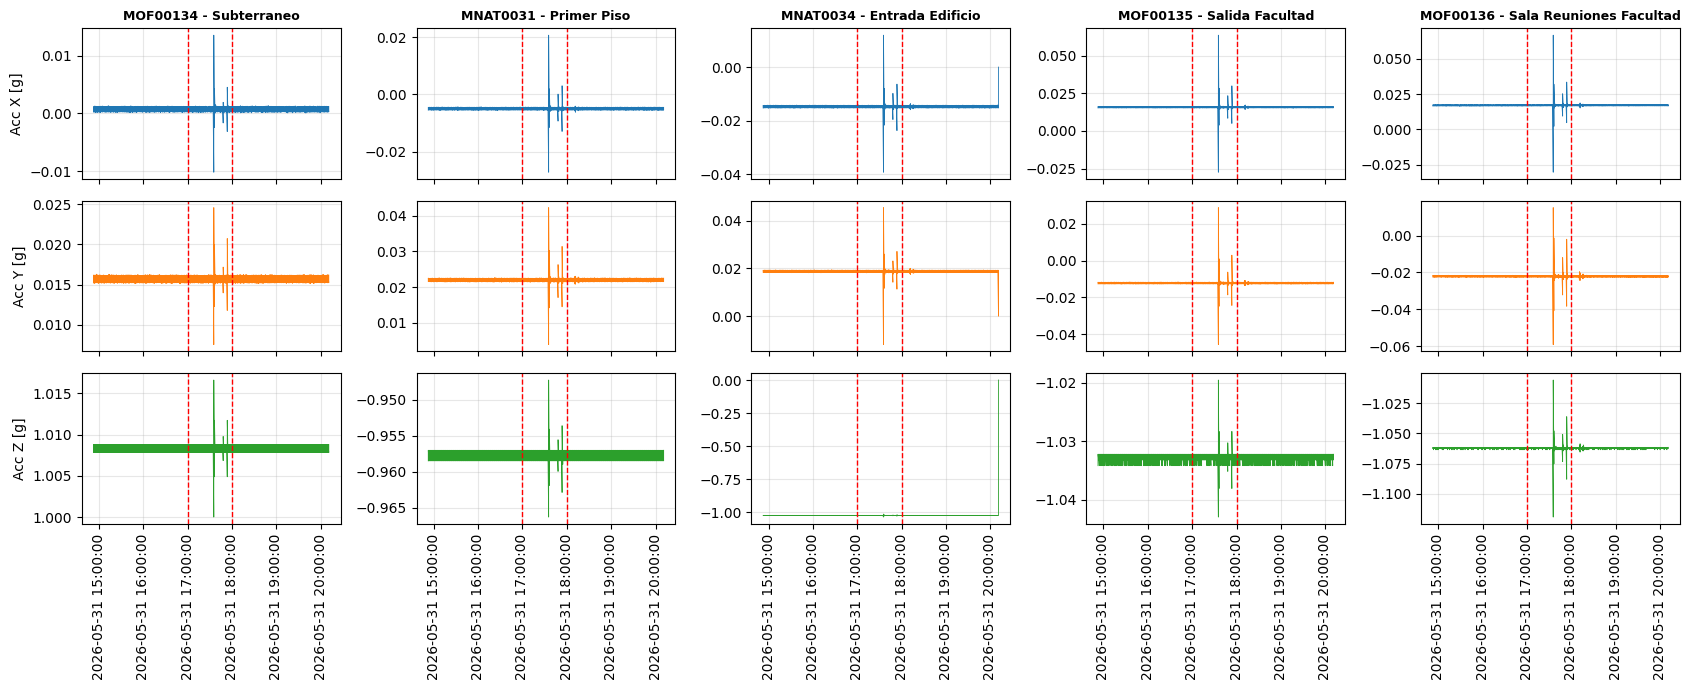

In [3]:
from asdea_sensors.plotting import overview_plots

# ---- inputs you tune ------------------------------------------------------
start_time = datetime(2026, 5, 31, 17, 0, 0)
end_time   = datetime(2026, 5, 31, 18, 0, 0)

DEVICES = ["MOF00134", "MNAT0031", "MNAT0034", "MOF00135", "MOF00136"]

titles = {
    "MOF00134": "Subterraneo",
    "MNAT0031": "Primer Piso",
    "MNAT0034": "Entrada Edificio",
    "MOF00135": "Salida Facultad",
    "MOF00136": "Sala Reuniones Facultad",
}
# ---------------------------------------------------------------------------

overview_plots.plot_overview(
    ds,
    devices=DEVICES,
    titles=titles,
    factor=1.0,
    unit="g",
    window=(start_time, end_time),
    figsize=(17, 7),
    # save="overview.pdf",
)

## 3. Accelerogram of all sensors

`group=True` overlays every sensor on the same axes (one row per component);
`group=False` draws one figure per sensor. `baseline=True` removes the DC
offset so the overlay is comparable.

[signal] MOF00134 n=896080 dt=0.004018 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0031' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MNAT0031 n=909340 dt=0.003959 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0034' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MNAT0034 n=907820 dt=0.003966 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00135' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00135 n=895400 dt=0.004021 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00136' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00136 n=903020 dt=0.003987 comps=all


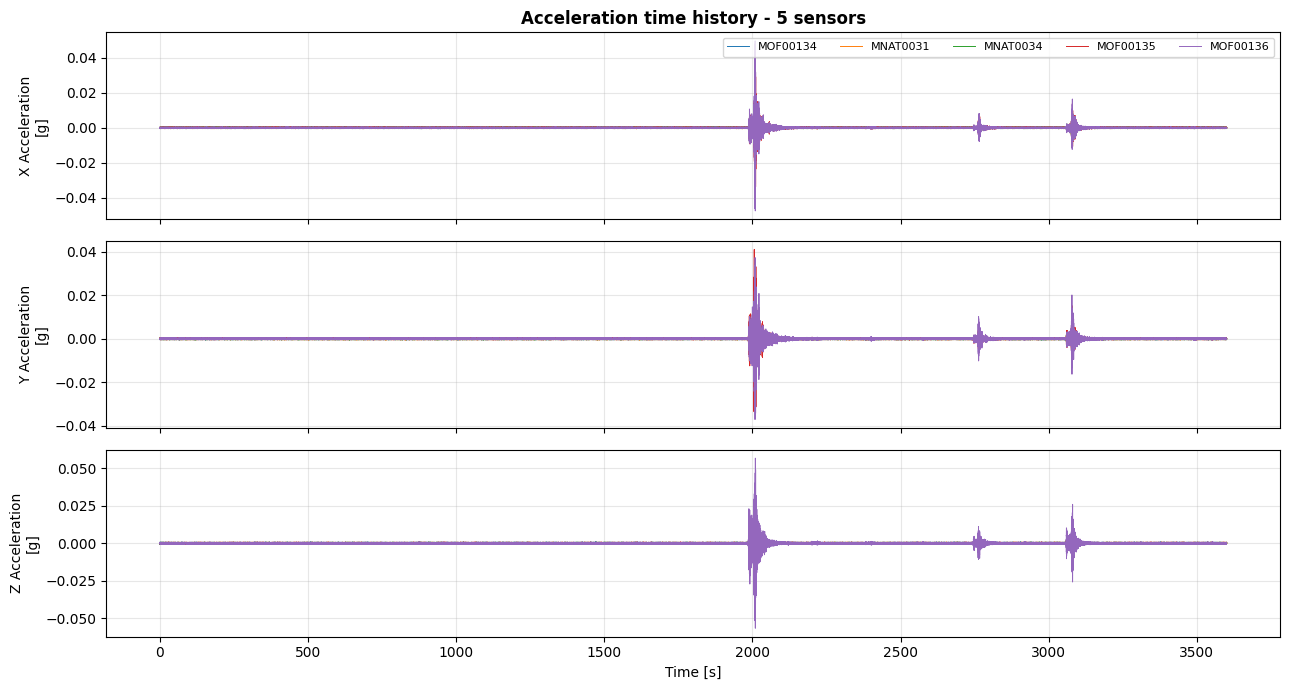

In [4]:
from asdea_sensors.plotting import signal_plots

signal_plots.plot_signals_all(
    ds,
    devices=DEVICES,
    start_time=start_time,
    end_time=end_time,
    components="all",
    kind="acc",
    factor=1/9.81,         # m/s^2 -> g
    unit="g",
    time_axis="relative",  # "absolute" (date) | "relative" (seconds)
    baseline=True,         # remove DC offset for a clean overlay
    fmin=None,             # no filter yet (raw accelerogram)
    fmax=None,
    group=True,            # overlay sensors; set False for one figure each
    figsize=(13, 7),
    xlim=None,
    ylim=None,
    # save="png",
)

## 4. Corrections and band-pass (inputs)

These feed every step below: baseline correction + a band-pass between
`FMIN` and `FMAX`.

In [5]:
BASELINE = True
FMIN, FMAX = 0.1, 24.9     # band-pass edges [Hz]

## 5. Fourier spectra of the filtered data (3 components, all sensors)

[signal] MOF00134 n=896080 dt=0.004018 comps=all


[signal] MNAT0031 n=909340 dt=0.003959 comps=all


[signal] MNAT0034 n=907820 dt=0.003966 comps=all


[signal] MOF00135 n=895400 dt=0.004021 comps=all


[signal] MOF00136 n=903020 dt=0.003987 comps=all


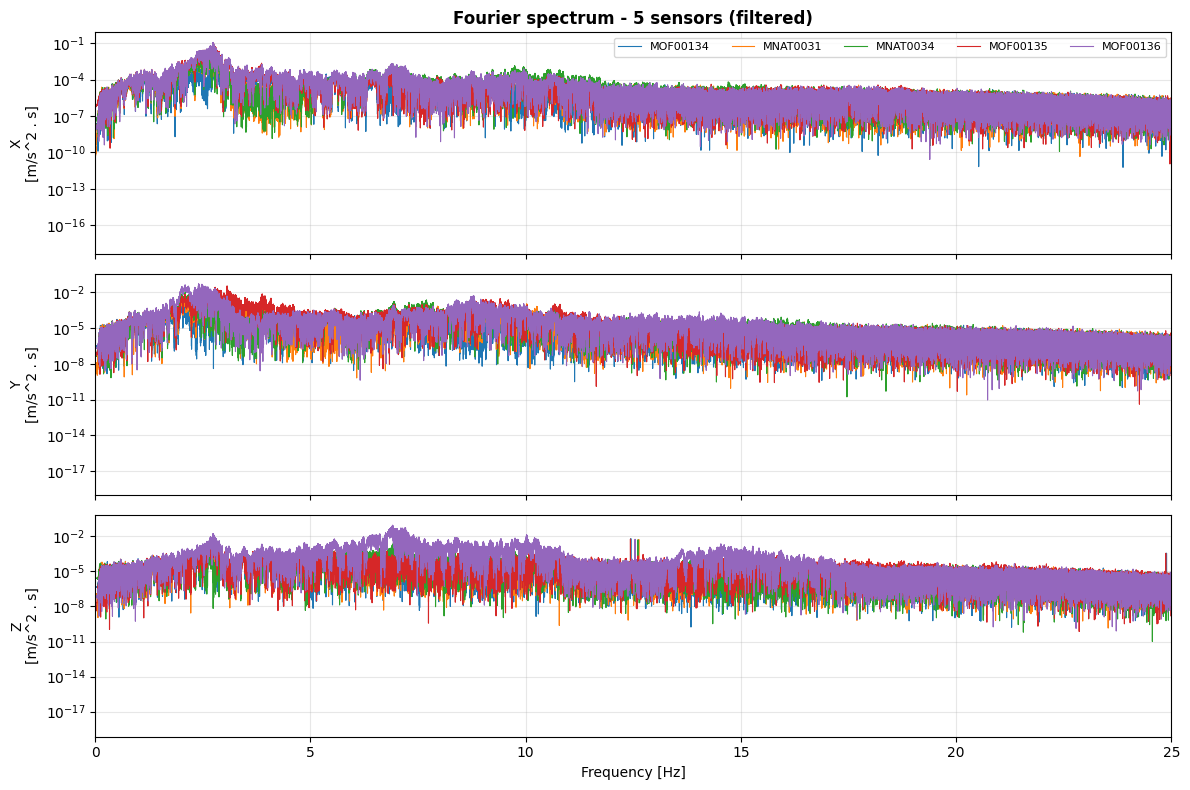

In [6]:
from asdea_sensors.plotting import fourier_plots

fourier_plots.plot_fourier_all(
    ds,
    devices=DEVICES,
    start_time=start_time,
    end_time=end_time,
    components=("x", "y", "z"),
    baseline=BASELINE,
    fmin=FMIN,
    fmax=FMAX,
    smooth=None,           # or "konno"
    overlay_raw=False,
    group=True,            # overlay sensors per component
    figsize=(12, 8),
    xlim=(0, 25),
    # save="fourier_all.pdf",
)

## 6. Fourier: filtered vs unfiltered (one figure per sensor)

[signal] MOF00135 n=895400 dt=0.004021 comps=all


[signal] MOF00135 n=895400 dt=0.004021 comps=all


[signal] MOF00134 n=896080 dt=0.004018 comps=all


[signal] MOF00134 n=896080 dt=0.004018 comps=all


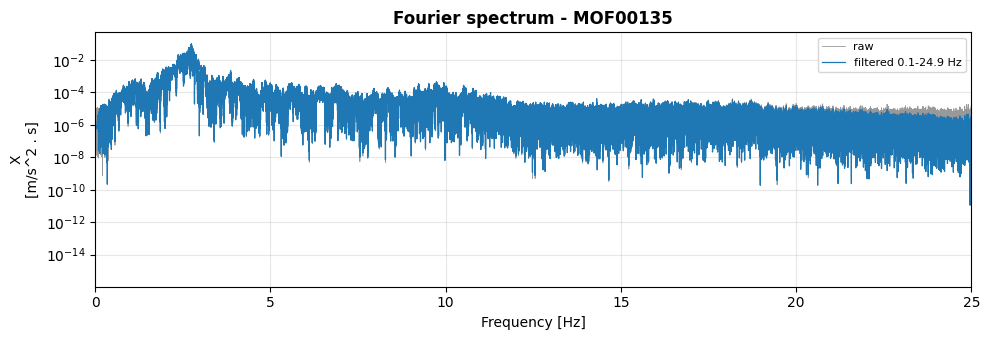

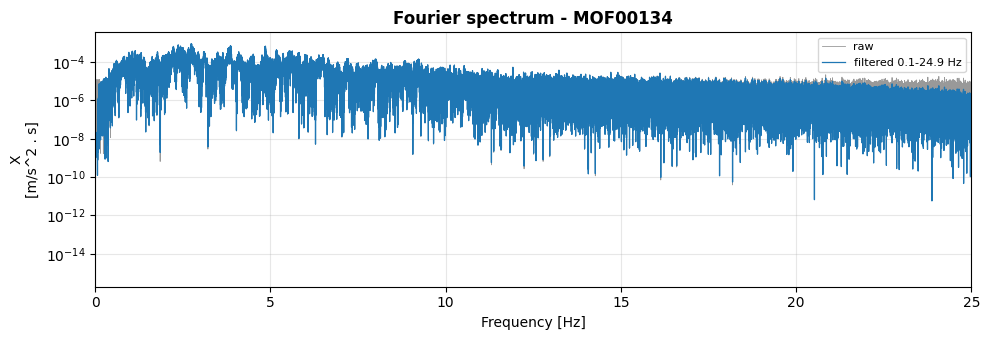

[None, None]

In [7]:
fourier_plots.plot_fourier_all(
    ds,
    devices=["MOF00135", "MOF00134"],   # a couple of sensors to compare
    start_time=start_time,
    end_time=end_time,
    components=("x",),
    baseline=BASELINE,
    fmin=FMIN,
    fmax=FMAX,
    overlay_raw=True,      # draw raw (grey) vs filtered (blue)
    group=False,
    figsize=(10, 3.5),
    xlim=(0, 25),
)

## 7. Predominant frequencies from the ambient (STA/LTA) windows

[signal] MOF00134 n=896080 dt=0.004018 comps=all


- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 176 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=40)
- average: mean spectrum computed (T=0.4166 s)


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0031' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MNAT0031 n=909340 dt=0.003959 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 179 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


...

[signal] MOF00135 n=895400 dt=0.004021 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 176 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=40)
- average: mean spectrum computed (T=0.3636 s)


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00136' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00136 n=903020 dt=0.003987 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 177 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=40)
- average: mean spectrum computed (T=0.3703 s)


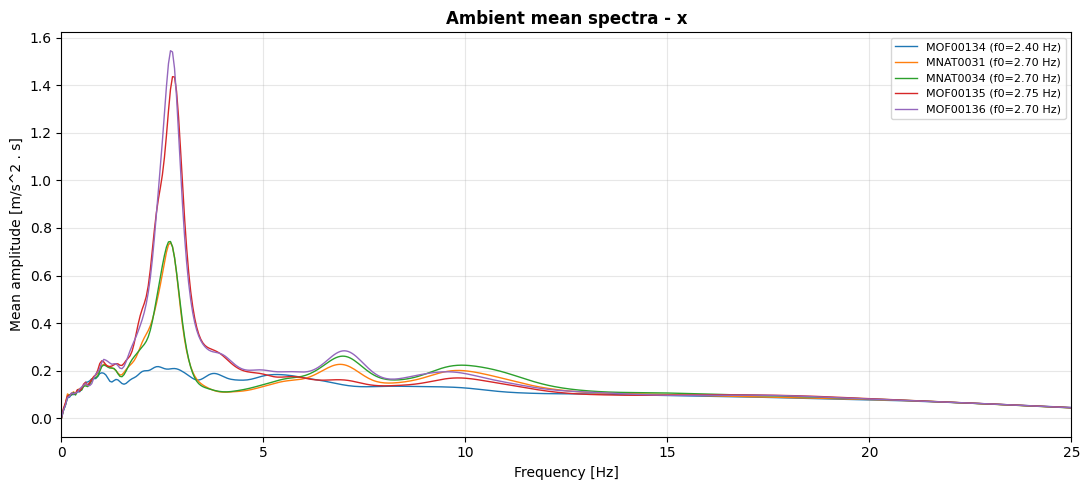

dominant frequency per sensor [Hz]: {'MOF00134': np.float64(2.4), 'MNAT0031': np.float64(2.7), 'MNAT0034': np.float64(2.7), 'MOF00135': np.float64(2.75), 'MOF00136': np.float64(2.7)}


In [8]:
from asdea_sensors.plotting import ambient_plots

config = {
    "Fs": ds.fs, "STA": 1.0, "LTA": 30.0,
    "vent": 20.0, "vmin": 0.0, "vmax": 1000.0,
    "p": 0.05, "bexp": 40, "f1": 0.1, "f2": 25.0, "vent_seismic": False,
}

f0 = ambient_plots.plot_mean_spectrum_all(
    ds,
    devices=DEVICES,
    start_time=start_time,
    end_time=end_time,
    config=config,
    component="x",
    baseline=BASELINE,
    fmin=FMIN,
    fmax=FMAX,
    group=True,
    figsize=(11, 5),
    xlim=(0, 25),
)
print("dominant frequency per sensor [Hz]:", {d: round(v, 2) for d, v in f0.items()})

## 8. Correlation between sensors (building)

Transfer function floor/base (its peaks are the building modal frequencies)
and coherence (trustworthy where it is close to 1).

[signal] MOF00134 n=896080 dt=0.004018 comps=x


[signal] MNAT0031 n=909340 dt=0.003959 comps=x


[signal] MNAT0034 n=907820 dt=0.003966 comps=x


[signal] MOF00135 n=895400 dt=0.004021 comps=x


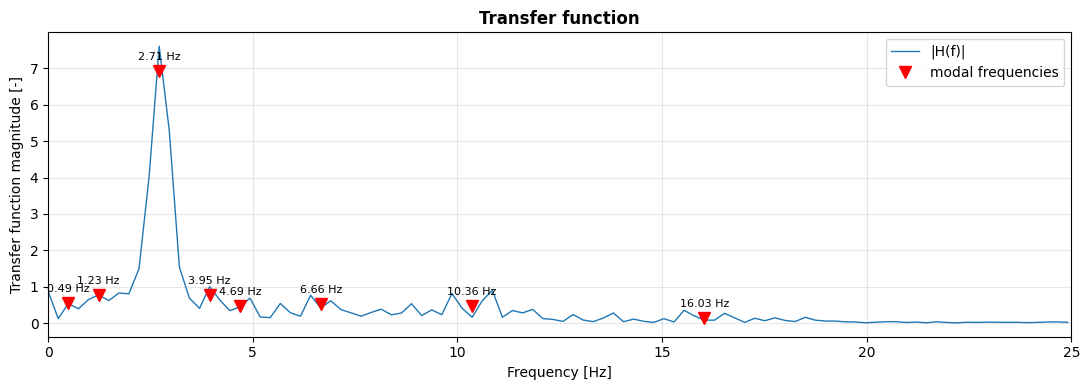

modal freqs (Hz): [0.49, 1.23, 2.71, 3.95, 4.69]


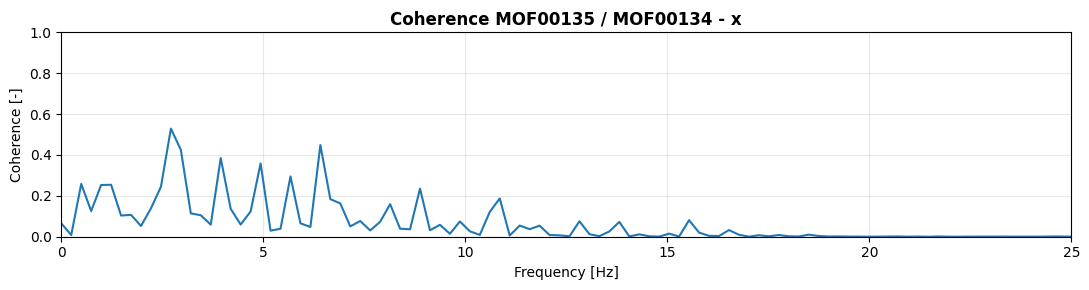

In [9]:
from asdea_sensors.building import transfer_function, coherence
from asdea_sensors.plotting import transfer_plots
import matplotlib.pyplot as plt

# read windowed, corrected, filtered x-component of the vertical array
sig = {d: ds.device(d).get_window(start_time, end_time)
              .baseline().filter(FMIN, FMAX, engine="scipy")
              .signal(components="x").acc_x
       for d in ["MOF00134", "MNAT0031", "MNAT0034", "MOF00135"]}
dt = ds.dt

top, base = sig["MOF00135"], sig["MOF00134"]
n = min(len(top), len(base))

frf = transfer_function.compute(top[:n], base[:n], dt, smooth="konno", fmax=25.0)
transfer_plots.plot_transfer_function(frf, figsize=(11, 4), xlim=(0, 25))
print("modal freqs (Hz):", [round(float(x), 2) for x in frf["modal_freqs"][:5]])

coh = coherence.compute(top[:n], base[:n], dt)
plt.figure(figsize=(11, 3))
plt.plot(coh["f"], coh["coherence"])
plt.xlim(0, 25); plt.ylim(0, 1)
plt.xlabel("Frequency [Hz]"); plt.ylabel("Coherence [-]")
plt.title("Coherence MOF00135 / MOF00134 - x", fontweight="bold")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()